## 5.1.3 Model 3: XGBoost Regressor

Gradient-boosted trees on the unscaled feature set — tree-based models don't need feature scaling. Target is `price`, already log-transformed upstream (Section 3.6), so all metrics below are computed on the log scale unless explicitly converted back to Ringgit (RM) with `np.exp`.

In [55]:
# 5.1.3 Model 3: XGBoost Regressor
# Trained on X_train.csv (unscaled) since tree-based models don't need feature scaling.

import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import json
from sklearn.model_selection import GridSearchCV
import sys, os

sys.path.append(os.path.dirname(os.path.abspath('__file__')))
from model_utils import evaluate_model, cross_validate_model

MODELLING_DIR = os.path.join("..", "data", "modelling")
MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

X_train = pd.read_csv(os.path.join(MODELLING_DIR, "X_train.csv"))
X_test = pd.read_csv(os.path.join(MODELLING_DIR, "X_test.csv"))

# price is already log-transformed in the CSV (see Section 3.6) — read as-is
y_train = pd.read_csv(os.path.join(MODELLING_DIR, "y_train.csv"))["price"]
y_test = pd.read_csv(os.path.join(MODELLING_DIR, "y_test.csv"))["price"]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (3004, 51) | X_test: (751, 51)


In [56]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold, cross_val_score

def rm_scale_rmse(y_true_log, y_pred_log):
    y_true_rm = np.exp(y_true_log)
    y_pred_rm = np.exp(y_pred_log)
    return np.sqrt(np.mean((y_true_rm - y_pred_rm) ** 2))

rm_rmse_scorer = make_scorer(rm_scale_rmse, greater_is_better=False)
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=42)

### Hyperparameter Tuning

**Baseline grid search (below, for reference)** covered `n_estimators`, `max_depth`, `learning_rate`, `subsample` only. It picked `max_depth=4, n_estimators=400` and scored well in CV (log-RMSE 0.25), but the fitted model showed a large train/test gap (Train R² 0.957 vs Test R² 0.750, 5-fold CV R² 0.711) — a classic overfitting signature for boosted trees: the search space had no regularization knobs, so the model was free to memorize training rows.

**Fixed below:** add `min_child_weight`, `gamma`, `reg_alpha`, `reg_lambda`, and `colsample_bytree` to the search, and switch to `RandomizedSearchCV` since the expanded grid is too large to search exhaustively. Also add early stopping on a held-out validation split so `n_estimators` self-tunes per candidate instead of being swept as a fixed grid value.

#### Step 1: Baseline Grid Search (for reference)

Covers only `n_estimators`, `max_depth`, `learning_rate`, `subsample` — no regularization. Kept for comparison against the expanded search below.

In [57]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
}

grid_search = GridSearchCV(
    xgb.XGBRegressor(random_state=42, objective="reg:squarederror", n_jobs=1),
    param_grid,
    scoring=rm_rmse_scorer,
    cv=cv_splitter,
    n_jobs=1,
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV score (RM-scale RMSE): {-grid_search.best_score_:.4f}")

# save tuning result for reference/reproducibility
with open(os.path.join(MODEL_DIR, "xgboost_best_params.json"), "w") as f:
    json.dump(grid_search.best_params_, f, indent=2)

Best params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 400, 'subsample': 0.8}
Best CV score (RM-scale RMSE): 168061.7422


#### Expanded search with regularization + early stopping

In [58]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint, uniform

# Held-out split from the training set for early stopping (X_test stays untouched until final eval)
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

param_distributions = {
    "n_estimators": randint(150, 600),
    "max_depth": randint(3, 7),
    "learning_rate": uniform(0.02, 0.11),        # ~0.02-0.15
    "subsample": uniform(0.6, 0.4),               # ~0.6-1.0
    "colsample_bytree": uniform(0.6, 0.4),        # ~0.6-1.0
    "min_child_weight": randint(1, 8),
    "gamma": uniform(0, 0.3),
    "reg_alpha": uniform(0, 1.5),
    "reg_lambda": uniform(0.5, 3.0),               # ~0.5-4.0
}

base_estimator = xgb.XGBRegressor(
    random_state=42, 
    objective="reg:squarederror", 
    eval_metric="rmse",
    n_jobs=1,
)

random_search = RandomizedSearchCV(
    base_estimator,
    param_distributions=param_distributions,
    n_iter=80,
    scoring=rm_rmse_scorer,
    cv=cv_splitter,
    n_jobs=1,
    random_state=42,
    verbose=1,
)

# eval_set needed for early stopping — passed via fit_params
random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print(f"Best CV score (RM-scale RMSE): {-random_search.best_score_:.4f}")

os.makedirs(MODEL_DIR, exist_ok=True)
with open(os.path.join(MODEL_DIR, "xgboost_best_params.json"), "w") as f:
  json.dump(random_search.best_params_, f, indent=2)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'colsample_bytree': np.float64(0.882033745718664), 'gamma': np.float64(0.07461724632908638), 'learning_rate': np.float64(0.056327778192100844), 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 322, 'reg_alpha': np.float64(0.017030467151128603), 'reg_lambda': np.float64(1.905981925982379), 'subsample': np.float64(0.6225213102727349)}
Best CV score (RM-scale RMSE): 165956.5578


> **Tuning notes / things worth trying next if the gap is still large:**
> - `max_depth` search range is currently set to 3-6(see `param_distributions` below). If Test R² still doesn’t close the gap, consider lowering the floor to 2–3 as well — shallower trees regularize more directly than L1/L2 alone.
> - If `State_*` / `PropertyType_*` one-hot columns dominate importance (they do, per the feature-importance table below), consider target encoding instead of one-hot — it can reduce the tree's tendency to split on rare state/property-type combinations.
> - `RandomizedSearchCV` is currently run with `n_iter=80`; increase further if compute budget allows, this is a reasonable starting point, not a ceiling.


#### Final Model Training

Use the tuned hyperparameters from `random_search`, find the right `n_estimators` via early stopping on the held-out validation split, then refit on the full training set with that fixed `n_estimators` (no early stopping needed on the final fit).

In [59]:
# Step 1: find the right n_estimators via early stopping (on X_fit/X_val only)
best_params = dict(random_search.best_params_)
best_params.pop("n_estimators", None)   # 加这一行，避免和下面的 n_estimators=1000 冲突

best_params.update({
    "random_state": 42,
    "objective": "reg:squarederror",
    "n_jobs": 1,
})

es_model = xgb.XGBRegressor(
    **best_params,
    eval_metric="rmse",
    n_estimators=1000,
    early_stopping_rounds=30,
)
es_model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
best_n_estimators = es_model.best_iteration +1
print(f"Early-stopped iteration: {best_n_estimators}")

# Step 2: refit on the FULL X_train with that fixed n_estimators, no early stopping
final_params = dict(best_params)
final_params["n_estimators"] = best_n_estimators

model = xgb.XGBRegressor(**final_params)
model.fit(X_train, y_train)
print("Model trained on full X_train.")

Early-stopped iteration: 272
Model trained on full X_train.


### Evaluation Metrics

Same `evaluate_model` helper as the baseline run — compare Train vs Test R² here against the 0.957 / 0.750 baseline gap to check whether regularization actually helped, not just whether CV score improved.

In [60]:
train_metrics = evaluate_model(model, X_train, y_train, label="Train")
print()
test_metrics = evaluate_model(model, X_test, y_test, label="Test")

# save metrics for report reference
with open(os.path.join(MODEL_DIR, "xgboost_metrics.json"), "w") as f:
    json.dump({"train": train_metrics, "test": test_metrics}, f, indent=2)

Train RMSE:  RM 111,218  (31.8% of median price)
Train MAE:   RM 61,619
Train MAPE:  15.4%
Train R2:    0.8849

Test RMSE:  RM 170,218  (47.3% of median price)
Test MAE:   RM 80,785
Test MAPE:  17.5%
Test R2:    0.7368


### 5-Fold Cross-Validation

In [61]:
cv_results = cross_validate_model(
    xgb.XGBRegressor(**final_params),
    X_train, y_train, n_splits=5,
)

5-fold CV (mean +/- std):
  RMSE:  RM 167,061 +/- 25,395  (47.5% of median price)
  MAE:   RM 79,876 +/- 4,173
  MAPE:  19.3% +/- 0.9%
  R2:    0.7345 +/- 0.0450


In [62]:
importance_table = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 15 features by importance:")
print(importance_table.head(15))

Top 15 features by importance:
Parking Lot                       0.103797
Has_Security                      0.094102
Has_Gymnasium                     0.091506
Has_Swimming_Pool                 0.083036
PropertyType_Condominium          0.070299
Property Size                     0.066616
PropertyType_Service_Residence    0.049969
PropertyType_Flat                 0.045468
Bathroom                          0.036213
State_Penang                      0.034435
State_Selangor                    0.026966
Property_Age_Missing              0.022038
Parking_Lot_Missing               0.019408
Total_Units_Missing               0.018095
State_Melaka                      0.015218
dtype: float32


### Save Model

In [63]:
model_path = os.path.join(MODEL_DIR, "xgboost_model.pkl")
joblib.dump(model, model_path)
print(f"Model saved to {model_path}")

Model saved to ..\models\xgboost_model.pkl


### Demo: Reload & Predict on a Sample Row

In [64]:
# Demo: reload the saved model and predict on an existing test row
import joblib
model = joblib.load(os.path.join(MODEL_DIR, "xgboost_model.pkl"))

sample = X_test.iloc[[0]]           # first row of X_test as a stand-in example
preds_log = model.predict(sample)
preds_rm = np.exp(preds_log)

print(f"Predicted price: RM {preds_rm[0]:,.0f}")
print(f"Actual price:    RM {np.exp(y_test.iloc[0]):,.0f}")

Predicted price: RM 353,273
Actual price:    RM 390,000


### Residual Analysis

Plots residuals (actual − predicted, in RM) on the test set to see where the model struggles most — e.g. underpricing high-end listings, or systematic bias in one price band.

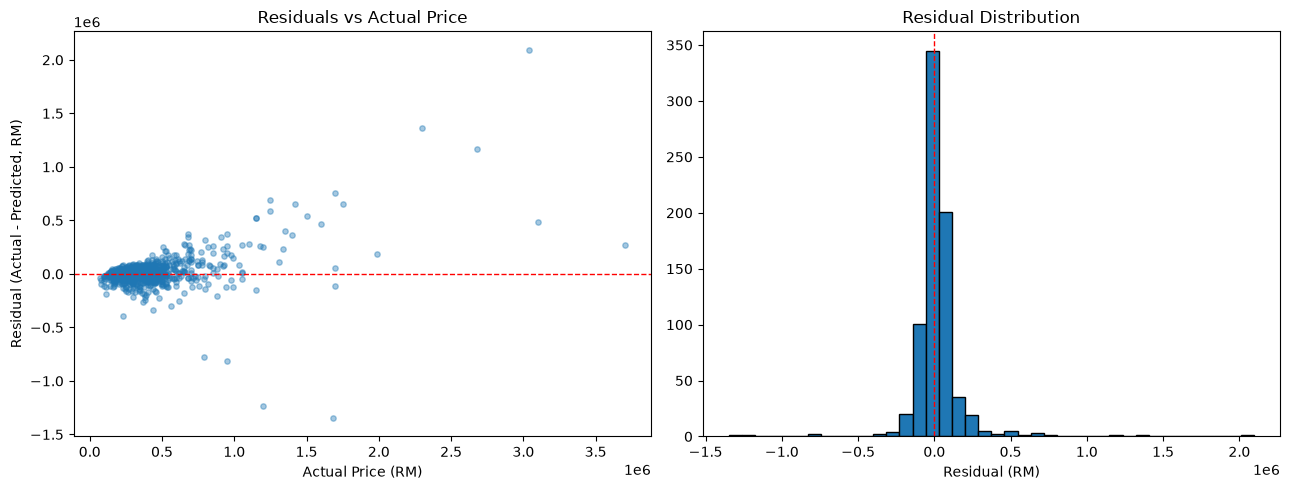

Mean residual (bias): RM 16,880
Residual std:         RM 169,492


,actual_rm,predicted_rm,abs_error_rm
685,3039000.0,9.446311e+05,2.094369e+06
727,2300000.0,9.324325e+05,1.367568e+06
438,1680000.0,3.026936e+06,1.346936e+06
56,1200000.0,2.432991e+06,1.232991e+06
350,2680000.0,1.514890e+06,1.165110e+06
454,950000.0,1.761474e+06,8.114738e+05
617,790000.0,1.568967e+06,7.789674e+05
400,1700000.0,9.474007e+05,7.525993e+05
474,1250000.0,5.566842e+05,6.933158e+05
139,1750000.0,1.094816e+06,6.551844e+05


In [65]:
import matplotlib.pyplot as plt

test_preds_log = model.predict(X_test)
test_preds_rm = np.exp(test_preds_log)
test_actual_rm = np.exp(y_test)
residuals_rm = test_actual_rm - test_preds_rm

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs actual price — spot whether errors grow with price
axes[0].scatter(test_actual_rm, residuals_rm, alpha=0.4, s=15)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Actual Price (RM)")
axes[0].set_ylabel("Residual (Actual - Predicted, RM)")
axes[0].set_title("Residuals vs Actual Price")

# Distribution of residuals — spot skew / bias
axes[1].hist(residuals_rm, bins=40, edgecolor="black")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Residual (RM)")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"Mean residual (bias): RM {residuals_rm.mean():,.0f}")
print(f"Residual std:         RM {residuals_rm.std():,.0f}")

# Worst 10 predictions by absolute error — useful to eyeball for data issues / outlier listings
worst = pd.DataFrame({
    "actual_rm": test_actual_rm.values,
    "predicted_rm": test_preds_rm,
    "abs_error_rm": residuals_rm.abs().values,
}).sort_values("abs_error_rm", ascending=False).head(10)
worst

### Sanity Check: Log-Price Transform

In [66]:
print("y_test head (log-price):", y_test.head())
print("y_test dtype:", y_test.dtype)
print("Expected actual price (RM):", np.exp(y_test.iloc[0]))

y_test head (log-price): 0    12.873902
1    12.100712
2    12.089539
3    12.793859
4    12.206073
Name: price, dtype: float64
y_test dtype: float64
Expected actual price (RM): 389999.99999999924


## Diagnostic Visualizations

Feature importance, fit check, prediction accuracy, and the early-stopping curve.

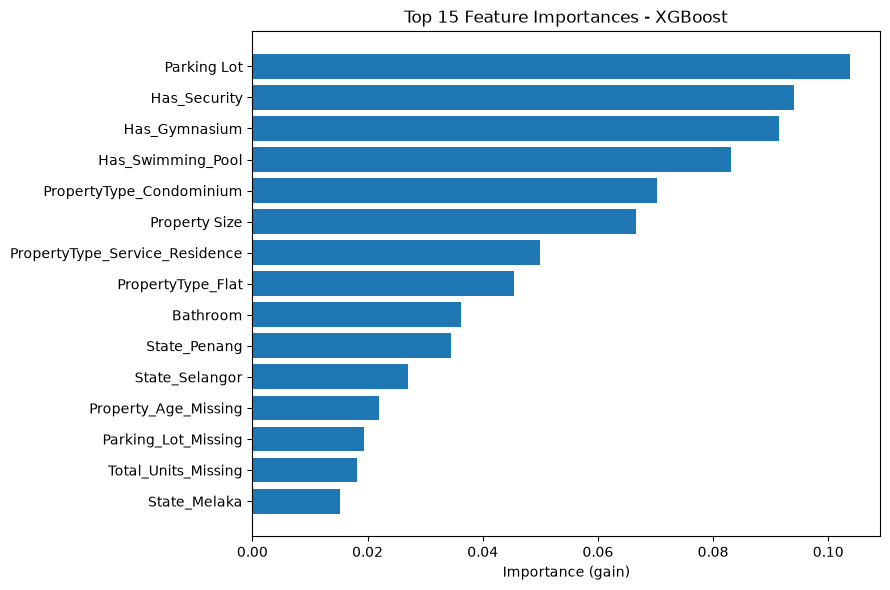

In [67]:
# Which features matter most to the model's predictions
import matplotlib.pyplot as plt

top15 = importance_table.head(15)
plt.figure(figsize=(9, 6))
plt.barh(top15.index[::-1], top15.values[::-1])
plt.xlabel("Importance (gain)")
plt.title("Top 15 Feature Importances - XGBoost")
plt.tight_layout()
plt.show()

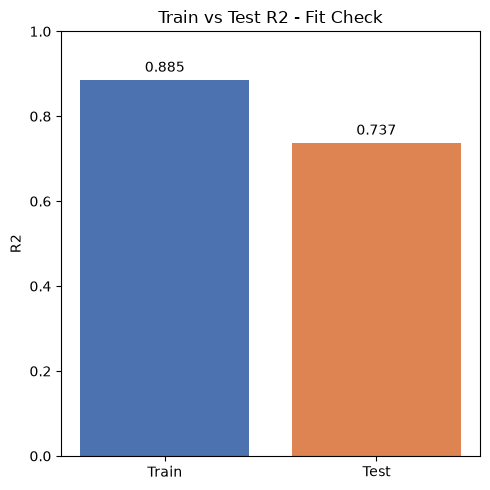

In [68]:
# CELL 2: Train vs Test R2
# Plain explanation: R2 closer to 1 means better predictions. If Train is
# much higher than Test, the model memorized the training data instead of
# learning general patterns (overfitting).
plt.figure(figsize=(5, 5))
plt.bar(["Train", "Test"], [train_metrics["R2"], test_metrics["R2"]], color=["#4C72B0", "#DD8452"])
plt.ylim(0, 1)
plt.ylabel("R2")
plt.title("Train vs Test R2 - Fit Check")
for i, v in enumerate([train_metrics["R2"], test_metrics["R2"]]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

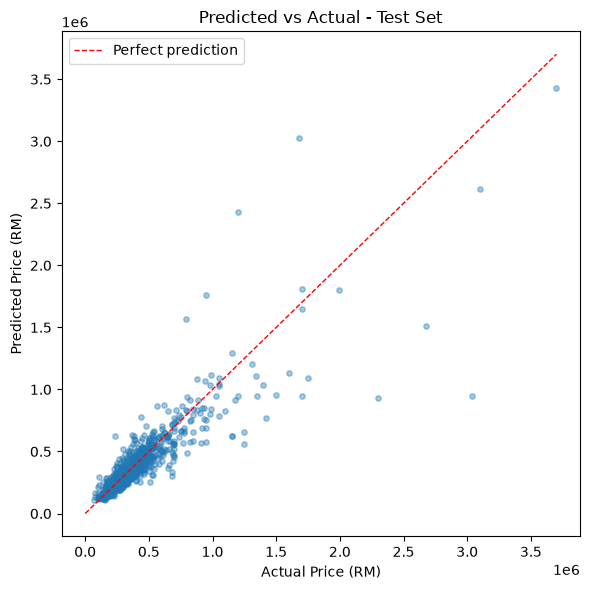

In [69]:
# CELL 3: Predicted vs Actual (Test set)
# Plain explanation: every dot is one house. Dots close to the red line mean
# the prediction matched the real price well. Dots far from the line are the
# model's biggest mistakes.
plt.figure(figsize=(6, 6))
plt.scatter(test_actual_rm, test_preds_rm, alpha=0.4, s=15)
lims = [0, max(test_actual_rm.max(), test_preds_rm.max())]
plt.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
plt.xlabel("Actual Price (RM)")
plt.ylabel("Predicted Price (RM)")
plt.title("Predicted vs Actual - Test Set")
plt.legend()
plt.tight_layout()
plt.show()


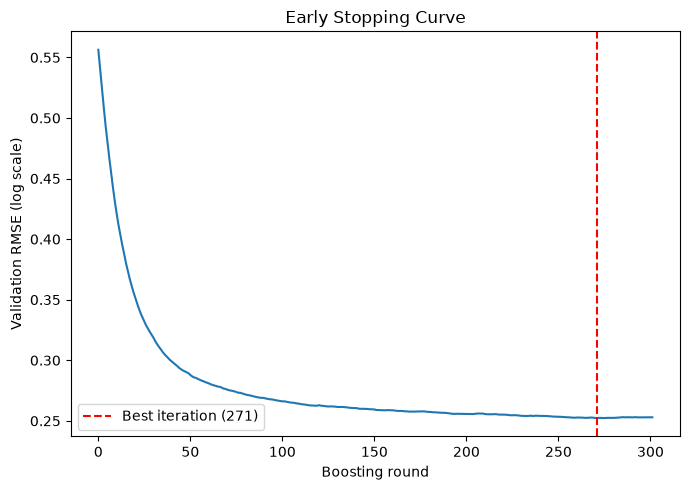

In [70]:
# CELL 4: Early Stopping Curve
# Plain explanation: each round adds one more tree. Error drops at first,
# then flattens or rises. The red dashed line marks where training stopped,
# because adding more trees was no longer helping.
results = es_model.evals_result()
plt.figure(figsize=(7, 5))
plt.plot(results["validation_0"]["rmse"])
plt.axvline(es_model.best_iteration, color="red", linestyle="--", label=f"Best iteration ({es_model.best_iteration})")
plt.xlabel("Boosting round")
plt.ylabel("Validation RMSE (log scale)")
plt.title("Early Stopping Curve")
plt.legend()
plt.tight_layout()
plt.show()


## Hyperparameter Sensitivity Analysis

For each tuned hyperparameter, sweep a range of values while holding the rest of best_params fixed, and plot Train vs 5-Fold CV R² (log scale) with the actually-tuned value marked. This shows why each value was a reasonable choice, not just what the value is.

learning_rate is analyzed separately below via CV R² as well, following the same Train/CV R² pattern as the other hyperparameters above.

In [71]:
def plot_param_effect(param_name, values, filename=None):
    """
    Sweep one XGBoost hyperparameter while holding the rest of `best_params` fixed,
    fit on X_train, and plot Train vs  CV R2. The tuned value is marked with a
    vertical line so the plot can be read as "why was this value chosen".
    Returns (train_r2_list, cv_r2_list).
    """
    train_r2_list, cv_r2_list = [], []

    for v in values:
        params = dict(final_params)
        params[param_name] = v

        temp_model = xgb.XGBRegressor(**params)
        temp_model.fit(X_train, y_train)
        train_r2 = temp_model.score(X_train, y_train)
        train_r2_list.append(train_r2)

        cv_scores = cross_val_score(
            temp_model,
            X_train,
            y_train,
            cv=cv_splitter,
            scoring="r2",
            n_jobs=1
        )
        cv_r2_list.append(np.mean(cv_scores))
    plt.figure(figsize=(7, 5))
    plt.plot(values, train_r2_list, marker="o", label="Train R2")
    plt.plot(values, cv_r2_list, marker="o", label="5-Fold CV R²")
    if param_name in final_params:
        plt.axvline(
            final_params[param_name],
            linestyle=":",
            label=f"Tuned value ({final_params[param_name]:.4f})"
        )
    plt.xlabel(param_name)
    plt.ylabel("R2")
    plt.title(f"Effect of {param_name} on Train/CV R²")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return train_r2_list, cv_r2_list


#### Effect of max_depth

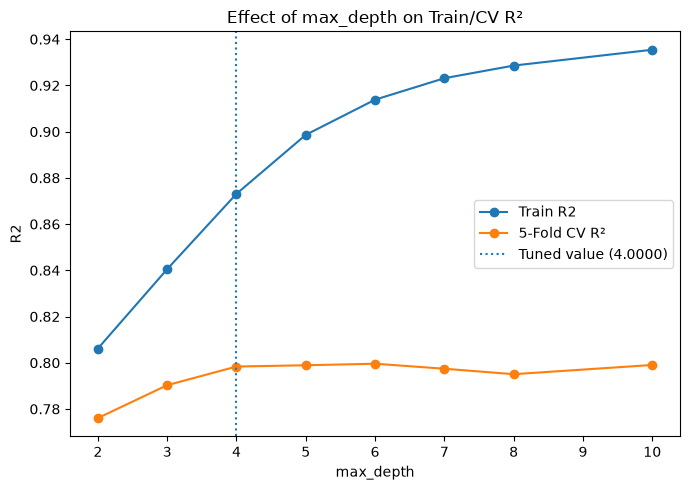

([0.8061621536522612,
  0.8405090418431673,
  0.8731108206541267,
  0.8986275552461969,
  0.9138446848782447,
  0.9231367129988137,
  0.928603519911062,
  0.9354498774344316],
 [np.float64(0.7760597441055535),
  np.float64(0.7902946806641646),
  np.float64(0.7983678797333834),
  np.float64(0.7989195277573655),
  np.float64(0.799581378543313),
  np.float64(0.7974158606967687),
  np.float64(0.7950512099477591),
  np.float64(0.7990402418809401)])

In [72]:
plot_param_effect("max_depth", [2, 3, 4, 5, 6, 7, 8, 10])

#### Effect of learning_rate

Plain explanation: learning_rate controls how fast each tree learns. Too slow and the model may not learn enough in time; too fast and it can overshoot and make worse guesses. The lowest point on this curve is the best rate for this data (within a fixed tree budget — the early-stopped n_estimators from the tuned model).

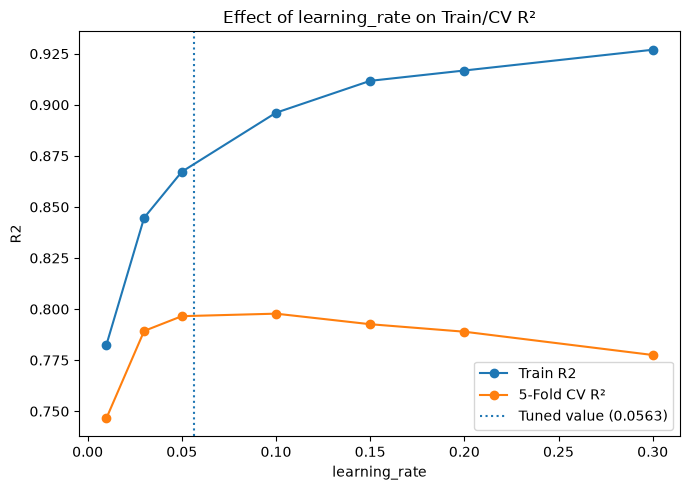

([0.7826256337805111,
  0.8447244126424003,
  0.8672363542565844,
  0.896117102532291,
  0.9117315429057471,
  0.9167897697247335,
  0.9269473664434419],
 [np.float64(0.7466580568433872),
  np.float64(0.7893073117753179),
  np.float64(0.7965381381604234),
  np.float64(0.7977684097631401),
  np.float64(0.7926028060181374),
  np.float64(0.7889339566606747),
  np.float64(0.7775365714625513)])

In [73]:
plot_param_effect(
    "learning_rate",
    [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3],
    filename="xgboost_learning_rate_effect.png"
)

#### Effect of gamma

Plain explanation: `gamma` sets the minimum loss reduction needed before a tree is allowed to split further. Higher `gamma` makes tree-building more conservative (fewer splits).

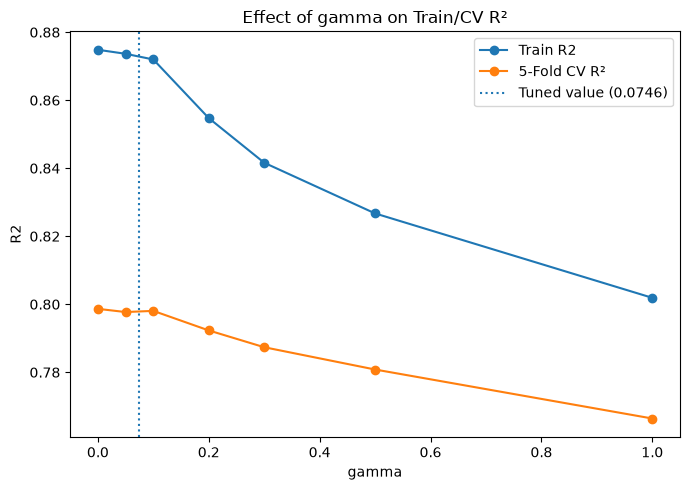

([0.8748397041849878,
  0.8736552448375159,
  0.8719855218100885,
  0.8547435400538508,
  0.8416172742639078,
  0.8267140560682406,
  0.8018963370074192],
 [np.float64(0.7986550687840307),
  np.float64(0.7977114341075596),
  np.float64(0.7980573723580514),
  np.float64(0.7923078407263006),
  np.float64(0.7873671926100516),
  np.float64(0.7808132389081436),
  np.float64(0.7664060488840798)])

In [74]:
plot_param_effect("gamma", [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0])

#### Effect of reg_alpha (L1)

Plain explanation: `reg_alpha` shrinks less-important leaf weights toward zero. Large values can zero out weak leaves entirely.

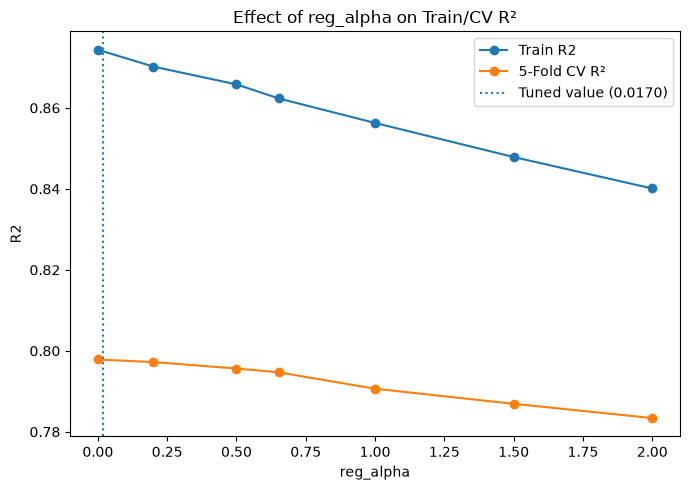

([0.8743715484869081,
  0.870214811772954,
  0.8658121516663113,
  0.8623323943623423,
  0.8562890687970858,
  0.8478671759178842,
  0.8401046386492079],
 [np.float64(0.7978584510534733),
  np.float64(0.797221537823417),
  np.float64(0.7956281698559804),
  np.float64(0.7946763834432545),
  np.float64(0.7906348717144857),
  np.float64(0.7869085713980641),
  np.float64(0.7833867790137198)])

In [75]:
plot_param_effect("reg_alpha", [0.0, 0.2, 0.5, 0.653, 1.0, 1.5, 2.0])

#### Effect of reg_lambda (L2)

Plain explanation: `reg_lambda` shrinks all leaf weights smoothly rather than zeroing them out, reducing model complexity as it increases.

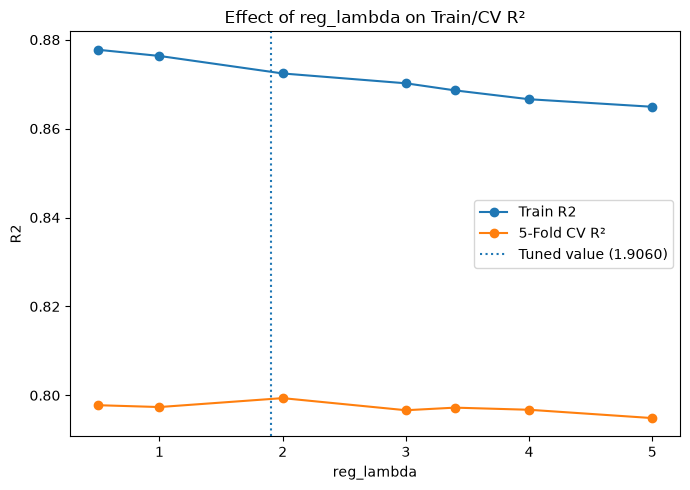

([0.8777457825047248,
  0.8763483338851824,
  0.8724116106505548,
  0.870198846433225,
  0.8686056429872396,
  0.8666158718868626,
  0.8649152356131051],
 [np.float64(0.7977823275360623),
  np.float64(0.7973684953115701),
  np.float64(0.7993734122254557),
  np.float64(0.7966505700020361),
  np.float64(0.7972321438976929),
  np.float64(0.7967561526636716),
  np.float64(0.7948853643511326)])

In [76]:
plot_param_effect("reg_lambda", [0.5, 1.0, 2.0, 3.0, 3.398, 4.0, 5.0])

#### Effect of subsample

Plain explanation: `subsample` controls what fraction of training rows each tree is grown on. Lower values add randomness between trees (helps generalization) but too low starves each tree of data.

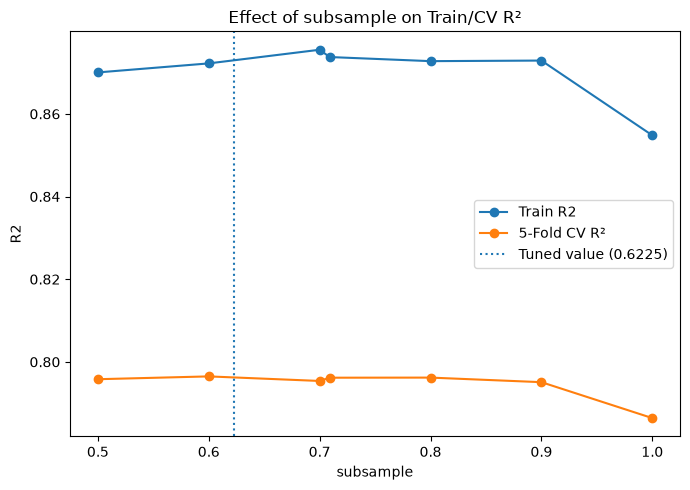

([0.8700405653622226,
  0.8722231298347974,
  0.8755252568017151,
  0.8737627104318223,
  0.8727673746188305,
  0.8729083701608591,
  0.8548197844959583],
 [np.float64(0.7958068747904739),
  np.float64(0.7964875660719324),
  np.float64(0.7953842353245912),
  np.float64(0.7961722006422145),
  np.float64(0.7961977281545992),
  np.float64(0.7950917288985732),
  np.float64(0.7864026310468857)])

In [77]:
plot_param_effect("subsample", [0.5, 0.6, 0.7, 0.709, 0.8, 0.9, 1.0])

#### Effect of colsample_bytree

Plain explanation: `colsample_bytree` controls what fraction of features each tree can consider — the column-wise version of `subsample`.

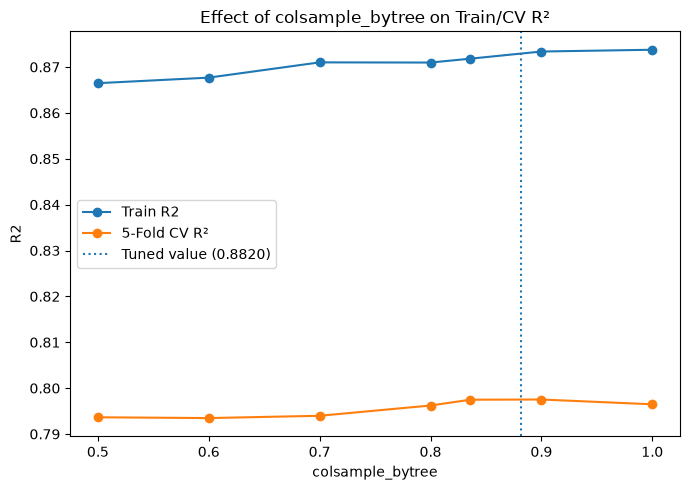

([0.8664727155639337,
  0.8676832627981718,
  0.8710080538264239,
  0.8709696717688354,
  0.8718170421112768,
  0.8733730349783327,
  0.873759362164925],
 [np.float64(0.7936480019675095),
  np.float64(0.7934729189880698),
  np.float64(0.7939753789078702),
  np.float64(0.7962141134187168),
  np.float64(0.7974770215122703),
  np.float64(0.797522064368674),
  np.float64(0.7964758595488319)])

In [78]:
plot_param_effect("colsample_bytree", [0.5, 0.6, 0.7, 0.8, 0.836, 0.9, 1.0])

#### Effect of min_child_weight

Plain explanation: `min_child_weight` sets the minimum amount of data needed in a leaf before it's allowed to exist. Higher values stop the model from creating leaves that only fit a handful of rows.

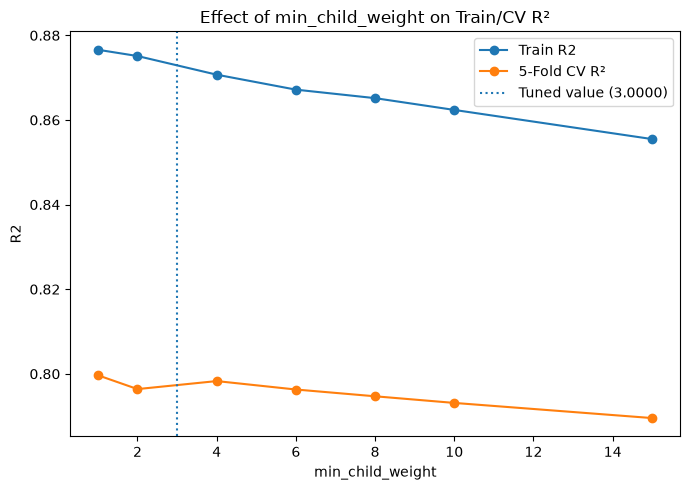

([0.8766017747373557,
  0.8751167437809572,
  0.870710275024194,
  0.8671721523394759,
  0.8651612669015233,
  0.8623772347045876,
  0.8554799569168984],
 [np.float64(0.7996628294371223),
  np.float64(0.7963918457949658),
  np.float64(0.7982838520552218),
  np.float64(0.7962909207901967),
  np.float64(0.7946895204228037),
  np.float64(0.7931216354967278),
  np.float64(0.7895387563270037)])

In [79]:
plot_param_effect("min_child_weight", [1, 2, 4, 6, 8, 10, 15])

### Environment / Package Versions

For reproducibility — pin these in `requirements.txt` if not already.

In [80]:
import pandas; pandas.__version__

'3.0.3'

In [81]:
import numpy; numpy.__version__

'2.5.1'

In [82]:
import matplotlib; matplotlib.__version__

'3.11.1'

In [83]:
import seaborn; seaborn.__version__

'0.13.2'

In [84]:
import joblib; joblib.__version__

'1.5.3'

In [85]:
import streamlit; streamlit.__version__ 

'1.59.2'